In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("bank.csv")
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')


In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

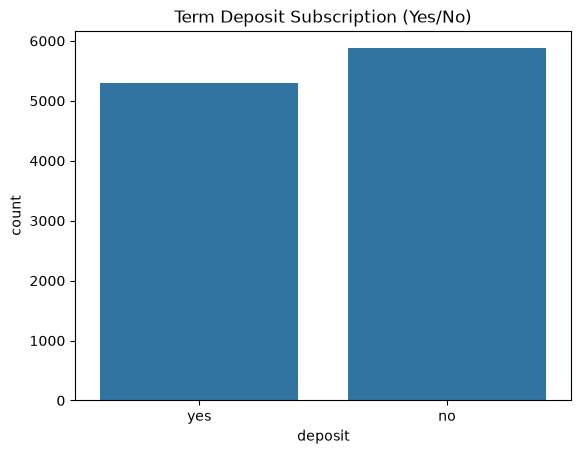

In [6]:
sns.countplot(x='deposit', data=df)
plt.title("Term Deposit Subscription (Yes/No)")
plt.show()

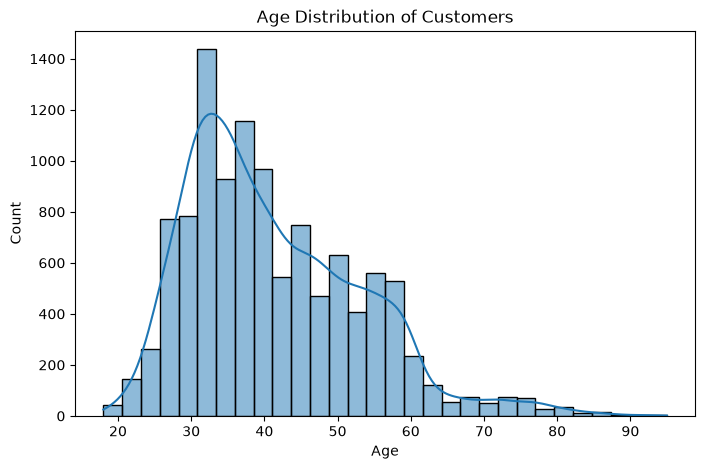

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.show()

In [8]:

total_by_job = df.groupby('job')['deposit'].count()
yes_by_job = df[df['deposit'] == 'yes'].groupby('job')['deposit'].count()
job_response = (yes_by_job / total_by_job) * 100
job_response = job_response.sort_values(ascending=False)

print(job_response)

job
student          74.722222
retired          66.323907
unemployed       56.582633
management       50.701481
unknown          48.571429
admin.           47.301349
self-employed    46.172840
technician       46.077894
services         39.978332
housemaid        39.781022
entrepreneur     37.500000
blue-collar      36.419753
Name: deposit, dtype: float64


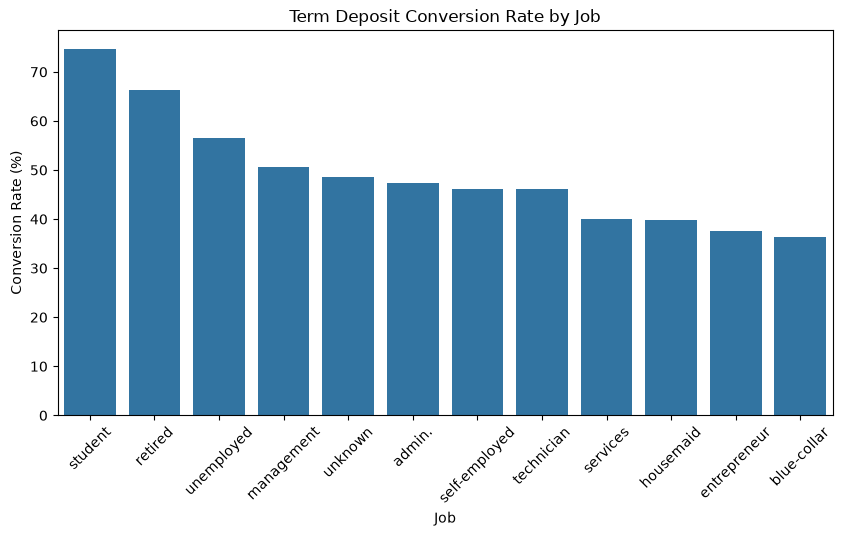

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(x=job_response.index, y=job_response.values)
plt.title("Term Deposit Conversion Rate by Job")
plt.xlabel("Job")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [10]:

total_by_edu = df.groupby('education')['deposit'].count()
yes_by_edu = df[df['deposit'] == 'yes'].groupby('education')['deposit'].count()
edu_response = (yes_by_edu / total_by_edu) * 100
edu_response = edu_response.sort_values(ascending=False)

print(edu_response)

education
tertiary     54.106804
unknown      50.704225
secondary    44.740687
primary      39.400000
Name: deposit, dtype: float64


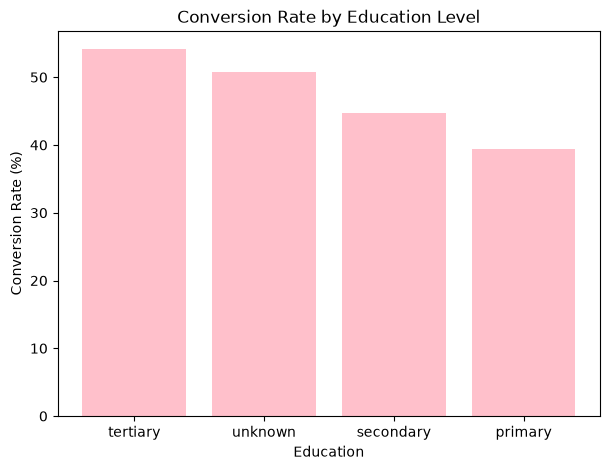

In [11]:
plt.figure(figsize=(7,5))
plt.bar(edu_response.index, edu_response.values, color='pink')
plt.title("Conversion Rate by Education Level")
plt.xlabel("Education")
plt.ylabel("Conversion Rate (%)")
plt.show()

In [12]:

total_by_month = df.groupby('month')['deposit'].count()

yes_by_month = df[df['deposit'] == 'yes'].groupby('month')['deposit'].count()

month_response = (yes_by_month / total_by_month) * 100
month_response = month_response.sort_values(ascending=False)

print(month_response)

month
dec    90.909091
mar    89.855072
sep    84.326019
oct    82.397959
apr    62.513543
feb    56.829897
aug    45.292956
jun    44.680851
nov    42.735949
jul    41.413474
jan    41.279070
may    32.754958
Name: deposit, dtype: float64


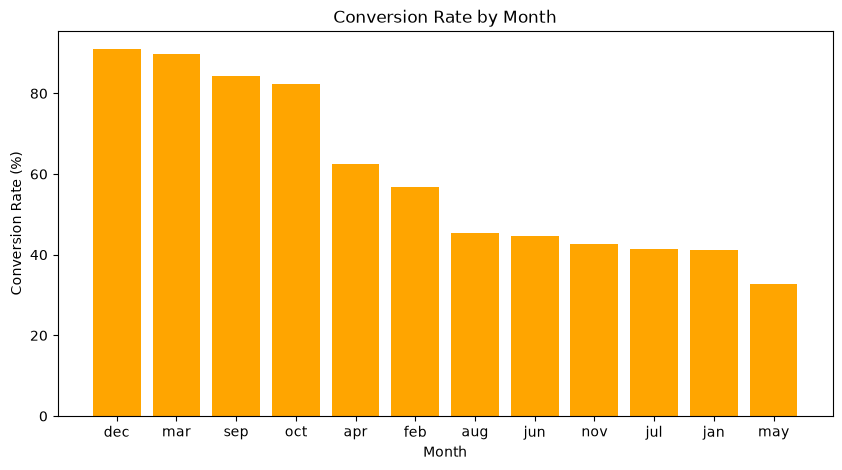

In [13]:
plt.figure(figsize=(10,5))
plt.bar(month_response.index, month_response.values, color='orange')
plt.title("Conversion Rate by Month")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.show()

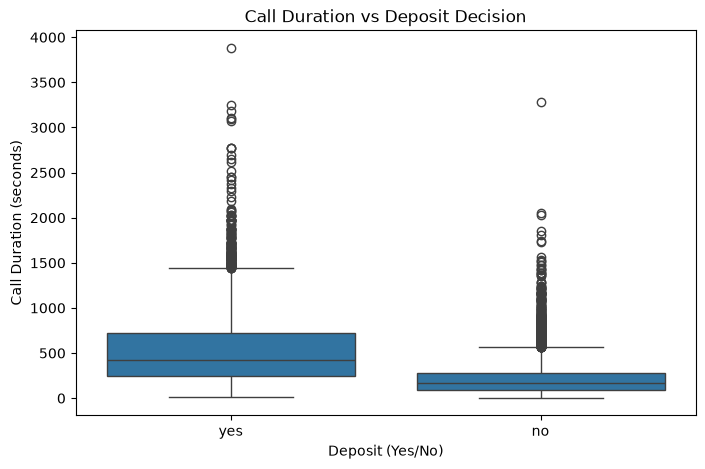

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='deposit', y='duration', data=df)
plt.title("Call Duration vs Deposit Decision")
plt.xlabel("Deposit (Yes/No)")
plt.ylabel("Call Duration (seconds)")
plt.show()

In [15]:
# Total customers
total_customers = len(df)

subscribed = (df['deposit'] == 'yes').sum()

conversion_rate = (subscribed / total_customers) * 100

print("Total Customers Contacted:", total_customers)
print("Customers who Subscribed:", subscribed)
print("Overall Conversion Rate:", round(conversion_rate, 2), "%")
print("Best performing job:", job_response.idxmax())
print("Best performing education level:", edu_response.idxmax())
print("Best performing month:", month_response.idxmax())

Total Customers Contacted: 11162
Customers who Subscribed: 5289
Overall Conversion Rate: 47.38 %
Best performing job: student
Best performing education level: tertiary
Best performing month: dec


In [16]:
total_by_housing = df.groupby('housing')['deposit'].count()
yes_by_housing = df[df['deposit'] == 'yes'].groupby('housing')['deposit'].count()
housing_response = (yes_by_housing / total_by_housing) * 100

print(housing_response)

housing
no     57.031117
yes    36.640788
Name: deposit, dtype: float64


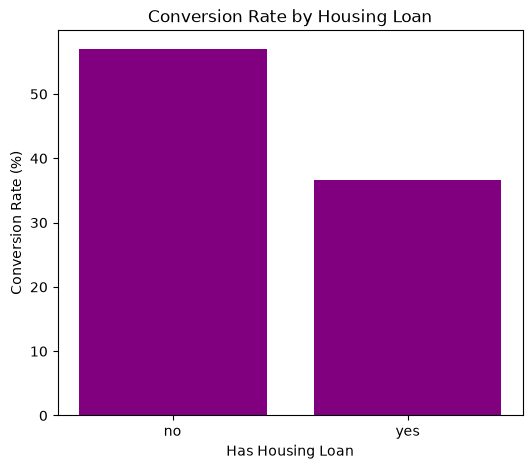

In [17]:
plt.figure(figsize=(6,5))
plt.bar(housing_response.index, housing_response.values, color='purple')
plt.title("Conversion Rate by Housing Loan")
plt.xlabel("Has Housing Loan")
plt.ylabel("Conversion Rate (%)")
plt.show()

In [18]:
total_by_poutcome = df.groupby('poutcome')['deposit'].count()
yes_by_poutcome = df[df['deposit'] == 'yes'].groupby('poutcome')['deposit'].count()
poutcome_response = (yes_by_poutcome / total_by_poutcome) * 100
poutcome_response = poutcome_response.sort_values(ascending=False)

print(poutcome_response)

poutcome
success    91.316527
other      57.169460
failure    50.325733
unknown    40.667788
Name: deposit, dtype: float64


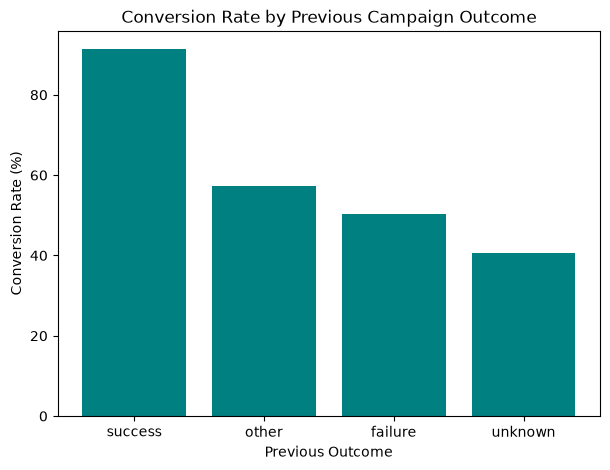

In [19]:
plt.figure(figsize=(7,5))
plt.bar(poutcome_response.index, poutcome_response.values, color='teal')
plt.title("Conversion Rate by Previous Campaign Outcome")
plt.xlabel("Previous Outcome")
plt.ylabel("Conversion Rate (%)")
plt.show()

In [20]:
avg_balance = df.groupby('deposit')['balance'].mean()
print(avg_balance)

deposit
no     1280.227141
yes    1804.267915
Name: balance, dtype: float64


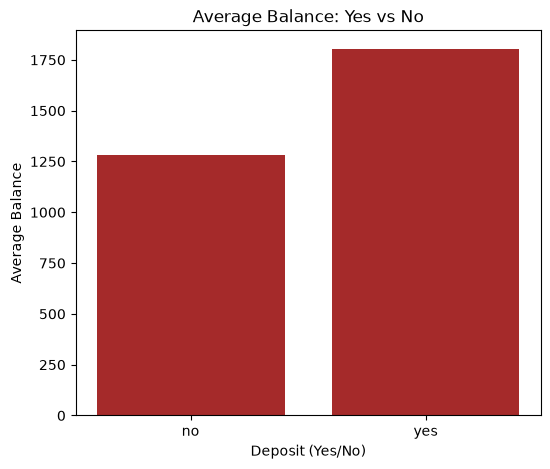

In [21]:
plt.figure(figsize=(6,5))
plt.bar(avg_balance.index, avg_balance.values, color='brown')
plt.title("Average Balance: Yes vs No")
plt.xlabel("Deposit (Yes/No)")
plt.ylabel("Average Balance")
plt.show()

In [22]:
total_customers = len(df)
subscribed = (df['deposit'] == 'yes').sum()
conversion_rate = (subscribed / total_customers) * 100

print("===== FINAL SUMMARY =====")
print("Total Customers Contacted:", total_customers)
print("Customers who Subscribed:", subscribed)
print("Overall Conversion Rate:", round(conversion_rate, 2), "%")
print()
print("Best performing job:", job_response.idxmax(), "-", round(job_response.max(), 2), "%")
print("Best performing education:", edu_response.idxmax(), "-", round(edu_response.max(), 2), "%")
print("Best performing month:", month_response.idxmax(), "-", round(month_response.max(), 2), "%")
print("Best previous outcome:", poutcome_response.idxmax(), "-", round(poutcome_response.max(), 2), "%")
print()
print("Avg Balance (Yes):", round(avg_balance['yes'], 2))
print("Avg Balance (No):", round(avg_balance['no'], 2))

===== FINAL SUMMARY =====
Total Customers Contacted: 11162
Customers who Subscribed: 5289
Overall Conversion Rate: 47.38 %

Best performing job: student - 74.72 %
Best performing education: tertiary - 54.11 %
Best performing month: dec - 90.91 %
Best previous outcome: success - 91.32 %

Avg Balance (Yes): 1804.27
Avg Balance (No): 1280.23


## Key Insights

1. **Overall conversion rate:** 47.38% (5,289 out of 11,162 customers subscribed)

2. **Job Type:** Students (74.7%) and Retired customers (66.3%) have the highest 
   conversion rates, while Blue-collar workers (36.4%) convert the least.

3. **Education:** Tertiary-educated customers (54.1%) convert more than 
   primary-educated customers (39.4%).

4. **Best Months:** December (90.9%), March (89.9%), September (84.3%), and 
   October (82.4%) had the highest success rates, while May (32.8%) performed worst.

5. **Previous Campaign Outcome:** Customers with a previous "success" outcome 
   converted 91.3% of the time — the strongest predictor in the dataset.

6. **Housing Loan:** Customers without a housing loan converted more (57.0%) 
   than those with one (36.6%).

7. **Call Duration:** Successful calls averaged 537 seconds vs. 223 seconds 
   for unsuccessful ones — longer conversations lead to more conversions.

8. **Balance:** Customers who subscribed had a higher average balance (1,804) 
   compared to those who didn't (1,280).

## Recommendation

The bank should prioritize students, retirees, and tertiary-educated customers, 
especially those with a prior successful outcome. Campaigns should focus on 
December, March, September, and October rather than May. Agents should aim for 
longer, quality conversations instead of rushing calls.